# Allen--Cahn: Generate Ground Truth Dataset

Runs the IMEX Allen-Cahn solver to generate the reference trajectory
and saves observations to an NPZ dataset used by `01_run_experiment.ipynb`.

**Problem:** Phase-field grain coarsening on $\Omega = (-0.5, 0.5)^2$,
Case 1 (constant mobility)

**PDE:**
$$\frac{\partial \phi}{\partial t} = \alpha^2 \Delta \phi - (\phi^3 - \phi), \quad \phi_0 \sim U(-0.9, 0.9)$$

**Observation model:** $Y_t = \arctan(X_t) + \varepsilon_t$, $\varepsilon_t \sim \mathcal{N}(0, \sigma_{obs}^2 I)$

**Output:** `../data/ac_dataset_case1.npz`

---
**Solver:** FEniCSx IMEX scheme (this work).  
**Reference experiment:** grain coarsening setup as used in Toan et al. (2026) https://arxiv.org/abs/2508.06834

In [1]:
import numpy as np
from pathlib import Path
from mpi4py import MPI
from dolfinx import fem

from solver import AllenCahnIMEX, create_mesh

## 1. Parameters

In [2]:
# Mesh
Nx, Ny = 128, 128

# Time discretization
dt     = 1e-2     # time step
Nstep  = 1000     # total steps  →  T = 10
T      = dt * Nstep

# Allen--Cahn
alpha         = 0.01   # interface width
mobility_case = 1      # constant mobility
xi_sigma      = 0.0    # no stochastic mobility perturbation

# Observation model
OBS_SIGMA     = 0.1
OBS_SUBSAMPLE = 4      # observe every 4th time step  →  250 obs times

# Seeds
SEED_IC  = 42
SEED_OBS = 123

# Output
DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## 2. Mesh and initial condition

In [3]:
domain, V = create_mesh(Nx=Nx, Ny=Ny)

imap, bs = V.dofmap.index_map, V.dofmap.index_map_bs
n_owned  = imap.size_local * bs

# Random initial condition phi_0 ~ U(-0.9, 0.9)
rng  = np.random.default_rng(SEED_IC)
phi0 = fem.Function(V, name="phi0")
phi0.x.array[:] = 1.8 * rng.random(phi0.x.array.size) - 0.9
phi0.x.scatter_forward()

print(f"State dimension (owned DOFs): {n_owned}")
print(f"Expected: {(Nx+1)*(Ny+1)} = {(Nx+1)*(Ny+1)}")

State dimension (owned DOFs): 16641
Expected: 16641 = 16641


## 3. Run solver

In [4]:
problem = AllenCahnIMEX(
    V,
    dt=dt,
    alpha=alpha,
    mobility_case=mobility_case,
    xi_sigma=xi_sigma,
)
problem.set_initial_condition(phi0)

solution, times, energies = problem.solve(Nstep=Nstep)

print(f"Solver finished. Steps: {len(solution)-1}, T = {times[-1]:.2f}")

Allen-Cahn solve: 100%|█████████████████████| 1000/1000 [00:36<00:00, 27.48it/s]

Solver finished. Steps: 1000, T = 10.00


## 4. Extract state trajectory and generate observations

In [5]:
# Full state array: shape (Nstep+1, n_owned)
X_true = np.vstack([f.x.array[:n_owned].copy() for f in solution])

# Subsample to observation times
X_true_obs = X_true[::OBS_SUBSAMPLE]          # (Nobs, n_owned)
t_obs      = np.array(times[::OBS_SUBSAMPLE]) # (Nobs,)
t_all      = np.array(times)                  # (Nstep+1,)

# Observations: Y = arctan(X) + noise
rng_obs = np.random.default_rng(SEED_OBS)
Y = np.arctan(X_true_obs) + OBS_SIGMA * rng_obs.normal(size=X_true_obs.shape)

print(f"X_true_obs shape: {X_true_obs.shape}")
print(f"Y shape:          {Y.shape}")
print(f"t_obs range:      [{t_obs[0]:.3f}, {t_obs[-1]:.3f}]")

X_true_obs shape: (251, 16641)
Y shape:          (251, 16641)
t_obs range:      [0.000, 10.000]


## 5. Quick diagnostics

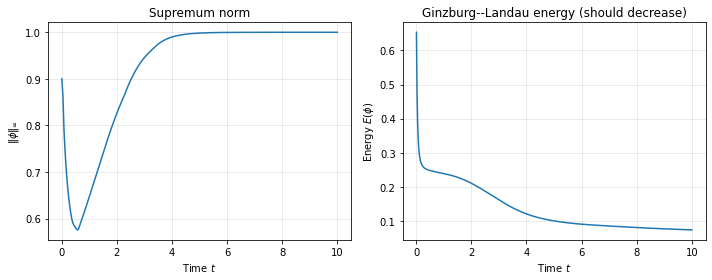

In [6]:
import matplotlib.pyplot as plt

supnorm = np.max(np.abs(X_true_obs), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t_obs, supnorm)
axes[0].set_xlabel("Time $t$")
axes[0].set_ylabel(r"$\|\phi\|_\infty$")
axes[0].set_title("Supremum norm")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_all[1:], energies)
axes[1].set_xlabel("Time $t$")
axes[1].set_ylabel("Energy $E(\phi)$")
axes[1].set_title("Ginzburg-Landau energy (should decrease)")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

assert np.all(np.diff(energies) <= 1e-6), "Energy not monotonically decreasing — check solver."

## 6. Save dataset

In [7]:
out_path = DATA_DIR / "ac_dataset_case1.npz"

np.savez(
    out_path,
    X_true_obs   = X_true_obs,
    Y            = Y,
    t_obs        = t_obs,
    energies     = energies,
    supnorm      = supnorm,
    # metadata
    dt           = dt,
    alpha        = alpha,
    Nstep        = Nstep,
    Nx           = Nx,
    Ny           = Ny,
    obs_sigma    = OBS_SIGMA,
    obs_subsample = OBS_SUBSAMPLE,
    mobility_case = mobility_case,
    xi_sigma     = xi_sigma,
    seed_ic      = SEED_IC,
    seed_obs     = SEED_OBS,
)

print(f"Dataset saved to {out_path}")

Dataset saved to ../data/ac_dataset_case1.npz
